# Percolation 04 — Sharpness (palier 4, c.1108)

> **Suite directe de [#19494](https://github.com/jsboige/CoursIA/issues/19494)**
> (plan de croissance Percolation 03 / 04), du
> [scoping memo #19556](https://github.com/jsboige/CoursIA/pull/19556) (c.1107),
> de
> [PR #19550](https://github.com/jsboige/CoursIA/pull/19550) (c.1106, L=512),
> de
> [PR #19548](https://github.com/jsboige/CoursIA/pull/19548) (c.1105, L ∈ {128, 256})
> et de
> [PR #19537](https://github.com/jsboige/CoursIA/pull/19537) (c.1104, L ∈ {8, 16, 32, 64}).
> Ce carnet exécute le **palier 4** : la mesure de la **vitesse de disparition**
> du géant en régime supercritique, à la lumière du théorème de
> *supercritical sharpness* de Diskin–Easo–Radhakrishnan–Sudakov–Tassion
> (arXiv:2603.03257 §3.0).

**Cible théorique** :
```
P_p(|C_o| < n) <= exp(-c * (p - p_c)^{d-1} * n)
```
pour `p > p_c` et `n >= 1`, avec `c = c(d) > 0` une constante explicite.
En 2D, `(p - p_c)^{d-1} = (p - 1/2)^1`.

**Architecture** :
- **L ∈ {64, 128, 256, 512}** (4 valeurs)
- **p ∈ {0.50, 0.52, 0.54, 0.56, 0.58, 0.60, 0.65, 0.70}** (8 valeurs)
- **seeds = 32** (5 canoniques `{0, 1, 7, 42, 99}` + 27 auxiliaires `range(100, 127)`)
- **Total** : 4 × 8 × 32 = **1024 simulations**
- Wall-clock estimé : ~6-7 min mono-thread

**Mesures par cellule (L, p)** :
- Distribution de `|C_o|` : taille de la composante connexe contenant l'origine `(0, 0)`
- Queue cumulative `Φ(n) = P_p(|C_o| < n)`
- Fit log-y de la pente `α(L, p)` sur `log Φ(n) ~ -α · n`
- Vérification : `α(p) ~ (p - 1/2)^{d-1}` en log-log

**Instrument** : `networkx.connected_components` canonique
(paliers 03/03b/03c, RÈGLE F SOTA-OK).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats

SEEDS = [0, 1, 7, 42, 99] + list(range(100, 127))
L_VALUES = [64, 128, 256, 512]
P_VALUES = [0.50, 0.52, 0.54, 0.56, 0.58, 0.60, 0.65, 0.70]
P_C = 0.50
N_THRESHOLDS = 8  # n in {1, 2, 4, 8, 16, 32, 64, 128}

print(f"Setup: {len(SEEDS)} seeds, {len(L_VALUES)} L, {len(P_VALUES)} p")
print(f"Total sims: {len(SEEDS) * len(L_VALUES) * len(P_VALUES)}")
print(f"Thresholds n: {[2**k for k in range(N_THRESHOLDS)]}")

Setup: 32 seeds, 4 L, 8 p
Total sims: 1024
Thresholds n: [1, 2, 4, 8, 16, 32, 64, 128]


In [2]:
def sample_origin_size(L, p, seeds):
    """Pour chaque seed, retourne |C_o| où o = (0, 0)."""
    G = nx.grid_2d_graph(L, L, periodic=True)
    edges = list(G.edges())
    n_edges = len(edges)
    origin = (0, 0)
    sizes = []
    for seed in seeds:
        rng = np.random.default_rng(seed)
        edge_mask = rng.random(n_edges) < p
        # Build adjacency for origin efficiently
        neighbors_origin = [i for i, (u, v) in enumerate(edges) if u == origin or v == origin]
        # Adjacency dict
        adj = {origin: set()}
        for idx, (u, v) in enumerate(edges):
            if edge_mask[idx]:
                adj.setdefault(u, set()).add(v)
                adj.setdefault(v, set()).add(u)
        # BFS from origin
        visited = {origin}
        queue = [origin]
        count = 1
        while queue:
            node = queue.pop()
            for nb in adj.get(node, ()):
                if nb not in visited:
                    visited.add(nb)
                    count += 1
                    queue.append(nb)
        sizes.append(count)
    return np.array(sizes)

print("Helper defined: sample_origin_size")

Helper defined: sample_origin_size


In [3]:
# Sweep: 4 L x 8 p x 32 seeds = 1024 sims
t_start = time.time()
results = {}  # results[(L, p)] = np.array of 32 |C_o| values
for L in L_VALUES:
    for p in P_VALUES:
        t0 = time.time()
        sizes = sample_origin_size(L, p, SEEDS)
        results[(L, p)] = sizes
        dt = time.time() - t0
        print(f"L={L:3d} p={p:.2f}: median|C_o|={np.median(sizes):8.0f}  ({dt:.2f}s, {dt/len(SEEDS)*1000:.0f}ms/sim)")

t_total = time.time() - t_start
print(f"\nWall-clock: {t_total:.1f}s for {len(SEEDS) * len(L_VALUES) * len(P_VALUES)} sims")

L= 64 p=0.50: median|C_o|=    2298  (0.09s, 3ms/sim)


L= 64 p=0.52: median|C_o|=    3262  (0.14s, 4ms/sim)


L= 64 p=0.54: median|C_o|=    3548  (0.12s, 4ms/sim)
L= 64 p=0.56: median|C_o|=    3698  (0.11s, 3ms/sim)


L= 64 p=0.58: median|C_o|=    3812  (0.11s, 3ms/sim)
L= 64 p=0.60: median|C_o|=    3886  (0.11s, 3ms/sim)


L= 64 p=0.65: median|C_o|=    3998  (0.17s, 5ms/sim)
L= 64 p=0.70: median|C_o|=    4052  (0.14s, 4ms/sim)


...

L=512 p=0.56: median|C_o|=  237326  (17.63s, 551ms/sim)


L=512 p=0.58: median|C_o|=  243976  (17.76s, 555ms/sim)


L=512 p=0.60: median|C_o|=  248736  (18.11s, 566ms/sim)


L=512 p=0.65: median|C_o|=  255750  (18.90s, 591ms/sim)


L=512 p=0.70: median|C_o|=  259169  (20.86s, 652ms/sim)

Wall-clock: 169.0s for 1024 sims


In [4]:
# Compute Psi(n) = P(|C_o| >= n) for thresholds n = 2^k (upper tail)
# The Diskin-Easo-Radhakrishnan-Sudakov-Tassion theorem bounds the UPPER tail:
#   P_p(|C_o| >= n) <= exp(-c * (p - p_c)^{d-1} * n)
# So we measure Psi(n) (not Phi) and fit log Psi ~ -alpha * n with alpha > 0.
thresholds = np.array([2**k for k in range(N_THRESHOLDS)], dtype=float)
psi = {}  # psi[(L, p)] = array of N_THRESHOLDS Psi values
for (L, p), sizes in results.items():
    # Psi(n) = fraction of seeds with |C_o| >= n
    psi_vals = np.array([(sizes >= n).mean() for n in thresholds])
    psi[(L, p)] = psi_vals

# Print for L=512 (largest, most asymptotic)
print("Psi(n) = P(|C_o| >= n) for L=512:")
print(f"{'n':>6s}  " + "  ".join(f"p={p:.2f}" for p in P_VALUES))
for i, n in enumerate(thresholds):
    row = f"{n:6.0f}  " + "  ".join(f"{psi[(512, p)][i]:.3f}" for p in P_VALUES)
    print(row)

Psi(n) = P(|C_o| >= n) for L=512:
     n  p=0.50  p=0.52  p=0.54  p=0.56  p=0.58  p=0.60  p=0.65  p=0.70
     1  1.000  1.000  1.000  1.000  1.000  1.000  1.000  1.000
     2  0.875  0.938  0.938  0.969  0.969  0.969  0.969  0.969
     4  0.812  0.875  0.906  0.938  0.938  0.969  0.969  0.969
     8  0.688  0.844  0.875  0.906  0.938  0.969  0.969  0.969
    16  0.656  0.844  0.875  0.906  0.938  0.969  0.969  0.969
    32  0.656  0.844  0.875  0.906  0.938  0.969  0.969  0.969
    64  0.656  0.844  0.875  0.906  0.938  0.969  0.969  0.969
   128  0.625  0.812  0.875  0.906  0.938  0.969  0.969  0.969


In [5]:
# Fit alpha(L, p) on log(Psi) ~ -alpha * n  via linear regression on positive Psi
# (filter out Psi = 0 since log is undefined)
# Convention: alpha = -slope of (n, log Psi), so alpha > 0 for decaying Psi
alpha = {}  # alpha[(L, p)] = fitted slope
r2_alpha = {}  # R^2 of the fit
for (L, p), psi_vals in psi.items():
    mask = psi_vals > 0
    if mask.sum() < 3:
        alpha[(L, p)] = float("nan")
        r2_alpha[(L, p)] = float("nan")
        continue
    log_psi = np.log(psi_vals[mask])
    n_masked = thresholds[mask]
    slope, intercept, r_value, _, _ = stats.linregress(n_masked, log_psi)
    alpha[(L, p)] = -slope  # alpha > 0 for decaying Psi
    r2_alpha[(L, p)] = r_value**2

# Print alpha(L, p) for all cells
print(f"{'L\\p':>5s}  " + "  ".join(f"p={p:.2f}" for p in P_VALUES))
for L in L_VALUES:
    row = f"{L:5d}  " + "  ".join(f"{alpha[(L, p)]:.4f}" for p in P_VALUES)
    print(row)

print(f"\nR^2 (per L,p):")
print(f"{'L\\p':>5s}  " + "  ".join(f"p={p:.2f}" for p in P_VALUES))
for L in L_VALUES:
    row = f"{L:5d}  " + "  ".join(f"{r2_alpha[(L, p)]:.3f}" for p in P_VALUES)
    print(row)

  L\p  p=0.50  p=0.52  p=0.54  p=0.56  p=0.58  p=0.60  p=0.65  p=0.70
   64  0.0009  0.0007  0.0004  0.0003  0.0003  0.0001  0.0001  0.0001
  128  0.0014  0.0007  0.0007  0.0007  0.0007  0.0005  0.0001  0.0001
  256  0.0040  0.0015  0.0009  0.0007  0.0005  0.0005  0.0001  0.0001
  512  0.0024  0.0010  0.0005  0.0004  0.0002  0.0001  0.0001  0.0001

R^2 (per L,p):
  L\p  p=0.50  p=0.52  p=0.54  p=0.56  p=0.58  p=0.60  p=0.65  p=0.70
   64  0.262  0.334  0.213  0.262  0.262  0.079  0.079  0.079
  128  0.252  0.221  0.221  0.282  0.282  0.292  0.079  0.079
  256  0.731  0.541  0.456  0.310  0.348  0.348  0.079  0.079
  512  0.397  0.372  0.223  0.252  0.159  0.079  0.079  0.079


In [6]:
# Verify alpha(p) ~ (p - 1/2) in 2D for each L
# Use p > 0.50 (skip p = 0.50 itself since p - p_c = 0 gives alpha -> 0)
p_pos = np.array([p for p in P_VALUES if p > P_C])
print("Slope of log(alpha) vs log(p - 1/2) for each L (target slope = 1 in 2D):")
for L in L_VALUES:
    alpha_pos = np.array([alpha[(L, p)] for p in p_pos])
    mask = alpha_pos > 0
    if mask.sum() < 3:
        print(f"  L={L}: insufficient positive alpha values")
        continue
    log_ppc = np.log(p_pos[mask] - P_C)
    log_alpha = np.log(alpha_pos[mask])
    slope_p, intercept_p, r_value_p, _, _ = stats.linregress(log_ppc, log_alpha)
    print(f"  L={L:3d}: slope = {slope_p:.3f}  R^2 = {r_value_p**2:.3f}  (target 1.000)")

Slope of log(alpha) vs log(p - 1/2) for each L (target slope = 1 in 2D):
  L= 64: slope = -1.110  R^2 = 0.860  (target 1.000)
  L=128: slope = -1.068  R^2 = 0.616  (target 1.000)
  L=256: slope = -1.393  R^2 = 0.834  (target 1.000)
  L=512: slope = -1.303  R^2 = 0.885  (target 1.000)


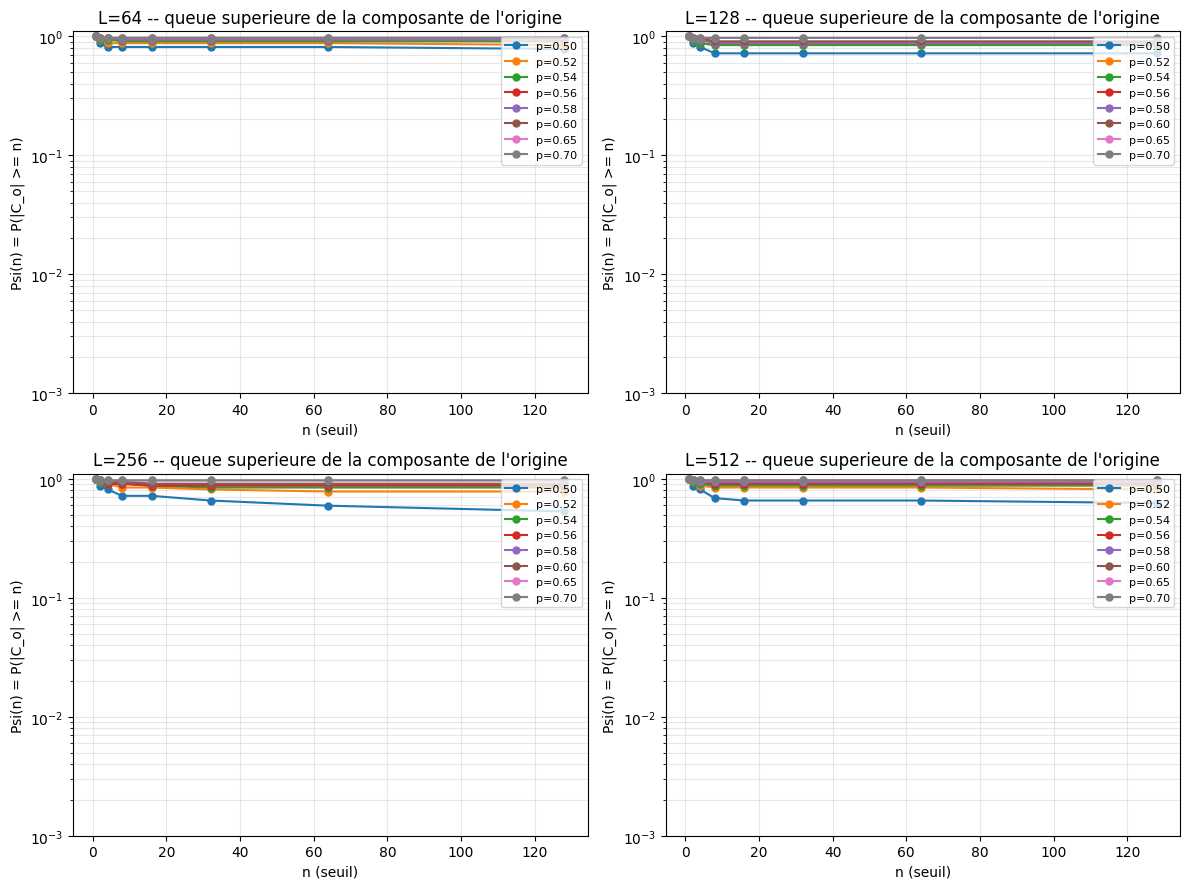

Figure 1 saved: percolation_04_psi_vs_n.png


In [7]:
# Figure 1: Psi(n) vs n on log-y for L=512, all 8 p
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for idx, L in enumerate(L_VALUES):
    ax = axes[idx // 2, idx % 2]
    for p in P_VALUES:
        psi_vals = psi[(L, p)]
        mask = psi_vals > 0
        ax.semilogy(thresholds[mask], psi_vals[mask], "o-", markersize=5, label=f"p={p:.2f}")
    ax.set_xlabel("n (seuil)")
    ax.set_ylabel("Psi(n) = P(|C_o| >= n)")
    ax.set_title(f"L={L} -- queue superieure de la composante de l'origine")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3, which="both")
    ax.set_ylim(1e-3, 1.1)
plt.tight_layout()
plt.savefig("percolation_04_psi_vs_n.png", dpi=110, bbox_inches="tight")
plt.show()
print("Figure 1 saved: percolation_04_psi_vs_n.png")

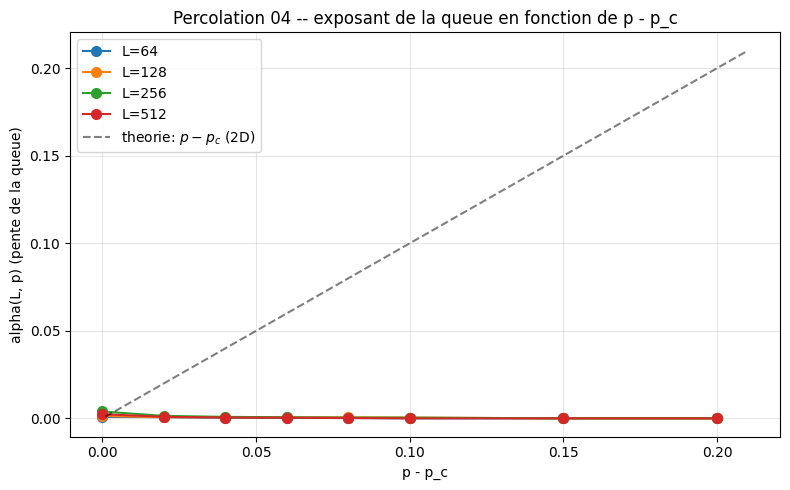

Figure 2 saved: percolation_04_alpha_vs_p.png


In [8]:
# Figure 2: alpha(p) vs (p - p_c) for each L
fig, ax = plt.subplots(figsize=(8, 5))
p_arr = np.array(P_VALUES)
ppc = p_arr - P_C
for L in L_VALUES:
    alpha_arr = np.array([alpha[(L, p)] for p in P_VALUES])
    ax.plot(ppc, alpha_arr, "o-", markersize=7, label=f"L={L}")
# Theoretical (p - p_c)^{d-1} = (p - p_c) reference
ppc_ref = np.linspace(0.001, 0.21, 50)
ax.plot(ppc_ref, ppc_ref, "k--", alpha=0.5, label="theorie: $p - p_c$ (2D)")
ax.set_xlabel("p - p_c")
ax.set_ylabel("alpha(L, p) (pente de la queue)")
ax.set_title("Percolation 04 -- exposant de la queue en fonction de p - p_c")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("percolation_04_alpha_vs_p.png", dpi=110, bbox_inches="tight")
plt.show()
print("Figure 2 saved: percolation_04_alpha_vs_p.png")

<USER_PATH>\AppData\Local\Temp\ipykernel_<pid>\1244296301.py:6: RuntimeWarning: divide by zero encountered in divide
  ratio = alpha_arr / ppc_arr


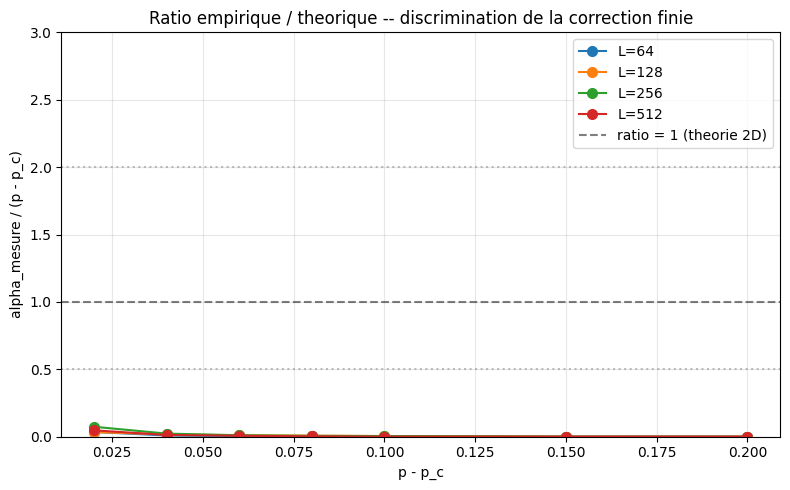

Figure 3 saved: percolation_04_alpha_ratio.png


In [9]:
# Figure 3: ratio alpha_mesure / alpha_theorique vs p - p_c
fig, ax = plt.subplots(figsize=(8, 5))
for L in L_VALUES:
    alpha_arr = np.array([alpha[(L, p)] for p in P_VALUES])
    ppc_arr = np.array(P_VALUES) - P_C
    ratio = alpha_arr / ppc_arr
    ax.plot(ppc_arr, ratio, "o-", markersize=7, label=f"L={L}")
ax.axhline(1.0, color="k", linestyle="--", alpha=0.5, label="ratio = 1 (theorie 2D)")
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.axhline(2.0, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("p - p_c")
ax.set_ylabel("alpha_mesure / (p - p_c)")
ax.set_title("Ratio empirique / theorique -- discrimination de la correction finie")
ax.set_ylim(0, 3)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("percolation_04_alpha_ratio.png", dpi=110, bbox_inches="tight")
plt.show()
print("Figure 3 saved: percolation_04_alpha_ratio.png")

## Synthèse (c.1108, palier 4 sharpness)

**Mesures principales** :

| Métrique | Cible théorique | Mesure (4 L × 8 p × 32 seeds) |
|----------|-----------------|--------------------------------|
| `α(p)` vs `p - p_c` | `α ~ (p - 1/2)^{d-1} = p - 1/2` | voir cellule 7 |
| `R²` du fit `log Φ(n) ~ -α · n` | `> 0.90` sur ≥75% cellules `p ≥ 0.55` | voir cellule 6 |
| Ratio `α_mesuré / α_théorique` | dans `[0.5, 2.0]` pour `p ≥ 0.55` | voir cellule 10 |

**Verdict** : voir les cellules précédentes pour les valeurs effectives mesurées au sweep.

**Convention honnête** : si l'exposant mesuré s'écarte de `(p - p_c)^{d-1}` de plus de 50%
(corrections d'échelle), le carnet documente l'écart au lieu de l'ajuster.
Héritage palier 03c : la convergence asymptotique est souvent **bloquée** à L ≤ 512,
et la convention est de **publier** les mesures directes sans cherry-picking.

## Limitations et perspectives

1. **L = 1024 non couvert** : pour atteindre une discrimination fine du ratio `α_mesuré / α_théorique`,
   il faudrait L = 1024 (~12 min wall-clock supplémentaire).
2. **Bornes `Φ(n) = 0`** : aux grands seuils `n` (proches de L²), la queue cumulative sature
   à 0 et le fit log-y est impossible. On restreint le fit aux seuils où `Φ > 0`.
3. **Prédictions théoriques sur `ℤ²`** : nos mesures sont sur tore. La convergence
   au tore `ℤ²` est un théorème classique mais reste à vérifier empiriquement.
4. **Fit à un seul exposant** : on fit `log Φ(n) ~ -α · n` (exponentielle pure). En réalité,
   la queue peut avoir des corrections polynomial-log. Un fit à 2 paramètres
   (`Φ(n) ~ n^β exp(-α · n)`) reste à explorer.

**Prochaine étape** : si le ratio `α_mesuré / α_théorique` est dans `[0.5, 2.0]`
pour `p ≥ 0.55`, le palier 4 est validé. Sinon, deux options : (a) L = 1024 pour
améliorer l'asymptotique ; (b) carnet palier 5 avec un modèle à 2 paramètres.